The function defined below determines whether or not a given DFA is synchronising using the pair graph. 


Iterate through each unique pair $(q_1, q_2)$ for distinct states $q_1$, $q_2$ $\in S$.

For each pair, perform a BFS using $\Sigma$.

Find if there is a word $w$ such that $\tau(q_1, w) = \tau(q_2, w)$.

If any unique pair does not satisfy $\tau(q_1, w) = \tau(q_2, w)$, for some $w$, in other words if there exits a pair that cannot be merged, then the DFA is not synchronising. 

Else each unique pair may be merged and the DFA is synchronising as per the following theorem: 

Suppose that for every pair of two distinct states $q_1, q_2 \in Q$ you can find a word $w_{q_1, q_2}$ over $\Sigma$ such that reading $w_{q_1, q_2}$ from either state leaves you in a common state $q_s$. Then $A$ is synchronising. 



In [25]:
# part c) Test if a given DFA is synchronising using the pair graph

from collections import deque

def is_synchronising_by_pair_graph(A):
    
    # Unpack 5-tuple.
    Q, sigma, tau, qs, F = A
    Q = sorted(list(Q))
    n = len(Q)

    # Loop through every unique pair (q1, q2).
    for i in range(n):
        for j in range(i + 1, n):
            q1, q2 = Q[i], Q[j]

            # Check if pair is mergeable using BFS.
            queue = deque([(q1, q2)])
            visited = {tuple(sorted((q1, q2)))}
            found_merge = False

            while queue:
                current_q1, current_q2 = queue.popleft()

                # First check if the pair is merged.
                if current_q1 == current_q2:
                    found_merge = True
                    break

                # Apply letters in turn.
                for alpha in sigma:
                    next_q1 = tau[(current_q1, alpha)]
                    next_q2 = tau[(current_q2, alpha)]

                    # Check for a merge.
                    if next_q1 == next_q2:
                        found_merge = True
                        break

                    # Append new pair to the queue.
                    next_pair = tuple(sorted((next_q1, next_q2)))
                    if next_pair not in visited:
                        visited.add(next_pair)
                        queue.append(next_pair)
                        
                if found_merge:
                    break

            if not found_merge:
                # DFA is certainly not synchronizing.
                return False
                
    # All pairs can be merged.
    return True

The following code finds and returns a reset word for the given DFA by starting from the set of all states, $Q$, and applying words to merge pairs until the set collapses to one state $\{q_s\}$. The below implementation starts with the merging of arbitrary states, and does not optimise the order of pairs merged in any way to reduce the length of the reset word it finds. The greedy heuristics of this method do not guarantee that the reset word found will be the shortest however it will always find a valid reset word by working forward from an arbitrary pair of states.

This is in contrast to the ancestor method which uses a BFS on all possible singleton sets $\{q_i\}$ for $1 \leq i \leq |Q|$. This backward search will find the shortest reset word, as it checks paths in increasing length (Breadth-First).



* Begin with the start state, $S = Q$.

* Choose two arbitrary distinct states $q_1$ and $q_2$ $\in S$.

* Implement a BFS to find the shortest word $w$ that merges $q_1$ and $q_2$.*

* Apply the word $w$ to every state in the current set $S$ to obtain a new set.

    $S_{new} = \{\tau(q, w) : q \in S\}$.

* Repeat and continue until the $|S| = 1$

*note that although the BFS finds the shortest word to merge two states in one step, the method will not merge all states to $\{q_s\}$ in the shortest possible number of uses of $\alpha \in \Sigma$.

In [26]:
# part e) Pair graph method to return a reset word. 

def find_reset_word_by_pair_graph(A):
    
    # Unpack 5-tuple
    Q, sigma, tau, qs, F = A
    current_set = set(Q)
    reset_word = []

    while len(current_set) > 1:
        # Choose two arbitrary states.
        states_list = sorted(list(current_set))
        q1, q2 = states_list[0], states_list[1]
        
        # Find the shortest word to merge these two states using BFS.
        queue = deque([((q1, q2), [])])
        visited = {tuple(sorted((q1, q2)))}
        found_merge = False

        while queue:
            (current_q1, current_q2), path = queue.popleft()

            # Try every symbol in the alphabet.
            for alpha in sigma:
                next_q1 = tau[(current_q1, alpha)]
                next_q2 = tau[(current_q2, alpha)]

                if next_q1 == next_q2:
                    # Then q1 and q2 are merged, add letter to word.
                    merge_path = path + [alpha]
                    reset_word.extend(merge_path)

                    # Now apply the word to the whole set.
                    for step_alpha in merge_path:
                        current_set = {tau[(s, step_alpha)] for s in current_set}

                    found_merge = True
                    break

                next_pair = tuple(sorted((next_q1, next_q2)))
                if next_pair not in visited:
                    visited.add(next_pair)
                    queue.append((next_pair, path + [alpha]))

            if found_merge:
                break
        else: 
        # No reset word exists.
            return None
    return reset_word

In [27]:
# function to draw DFA. 

import matplotlib.pyplot as plt
import networkx as nx

def draw_DFA(A):
    Q, sigma, tau, qs, F = A
    G = nx.MultiDiGraph()

    for (fromm, alpha), to in tau.items():
        G.add_edge(fromm, to, label = alpha)

    pos = nx.spring_layout(G)
    plt.figure()
    nx.draw(G, pos, with_labels = True)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    plt.show()

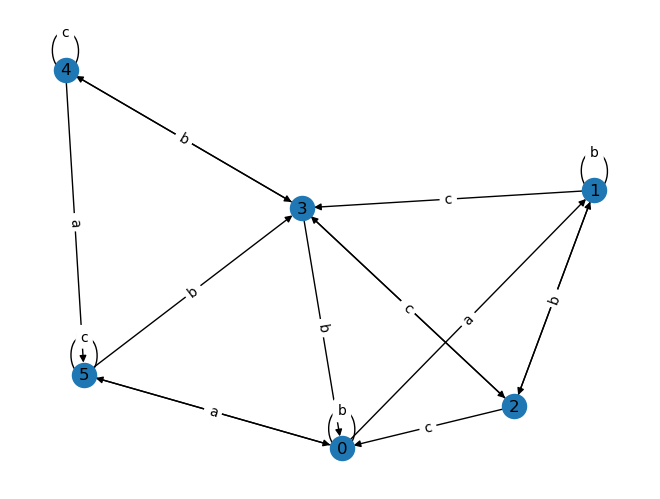

In [28]:
Q = {0, 1, 2, 3, 4, 5}
sigma = {'a', 'b', 'c'}
tau = {(0, 'a'): 1, (0, 'b'): 0, (0, 'c'): 5,
       (1, 'a'): 2, (1, 'b'): 1, (1, 'c'): 3,
       (2, 'a'): 3, (2, 'b'): 1, (2, 'c'): 0,
       (3, 'a'): 4, (3, 'b'): 0, (3, 'c'): 2, 
       (4, 'a'): 5, (4, 'b'): 3, (4, 'c'): 4, 
       (5, 'a'): 0, (5, 'b'): 3, (5, 'c'): 5}
qs = {}
F = {}
A = (Q, sigma, tau, qs, F)

draw_DFA(A)

In [29]:
print(is_synchronising_by_pair_graph(A))
print(find_reset_word_by_pair_graph(A))

True
['a', 'b', 'a', 'b', 'b', 'a', 'b']


In [30]:
# tester DFA 1. 

Q1 = {0, 1, 2}
sigma1 = {'a', 'b'}
tau1 = {(0, 'a'): 1, (1, 'a'): 2, (2, 'a'): 0, (0, 'b'): 1, (1, 'b'): 1, (2, 'b'):2}
qs1 = 0 
F1 = {2}
A1 = (Q1, sigma1, tau1, qs1, F1)

print(is_synchronising_by_pair_graph(A1))
print(find_reset_word_by_pair_graph(A1))

True
['b', 'a', 'a', 'b']


In [31]:
def is_synchronizing_word(word, A):
    Q, sigma, tau, qs, F = A

    current_state = set(Q)

    for alpha in word:
        next_state = set()
        for q in current_state:
            next_state.add(tau[(q, alpha)])

        current_state = next_state

    return len(current_state) == 1


reset_word = ['b', 'b', 'a', 'b']
is_synchronizing_word(reset_word, A)

True

In [32]:
Q2 = {0, 1, 2, 3}
sigma2 = {'a', 'b'}
tau2 = {(0, 'a'): 1, (0, 'b'): 0, (1, 'a'): 2, (1, 'b'): 1, (2, 'a'): 3, (2, 'b'): 2, (3, 'a'): 0, (3, 'b'): 0}
qs = {}
F = {}

cerny_A = (Q2, sigma2, tau2, qs, F)

print(is_synchronising_by_pair_graph(cerny_A))
print(find_reset_word_by_pair_graph(cerny_A))
res = find_reset_word_by_pair_graph(cerny_A)
is_synchronizing_word(res, cerny_A)

True
['a', 'a', 'a', 'b', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'b']


True

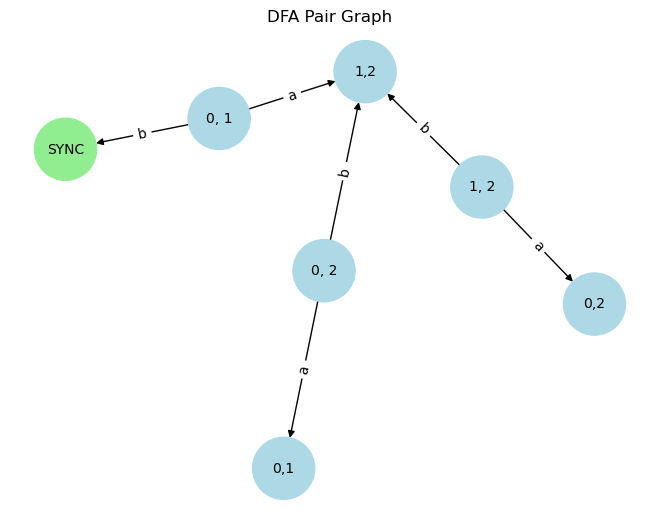

In [54]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_pair_graph(A):
    Q, sigma, tau, qs, F = A
    Q = sorted(list(Q))

    G = nx.DiGraph()
    
    sync_node = "SYNC"
    G.add_node(sync_node, colour = "green")
    
    pairs =  [tuple(sorted((Q[i], Q[j])))
              for i in range(len(Q))
              for j in range(i + 1, len(Q))]
   
    for q1, q2 in pairs:
        pair_node = f"{q1}, {q2}"
        for alpha in sigma:
            next_q1 = tau[(q1, alpha)]
            next_q2 = tau[(q2, alpha)]

            if next_q1 == next_q2:
                G.add_edge(pair_node, sync_node, label = alpha)
            else:
                next_pair = tuple(sorted((next_q1, next_q2)))
                target_node = f"{next_pair[0]},{next_pair[1]}"
                G.add_edge(pair_node, target_node, label = alpha)

    plt.figure()
    pos = nx.spring_layout(G)

    node_colours = ['#90ee90' if n == sync_node else '#add8e6' for n in G.nodes()]
    nx.draw(G, pos, with_labels = True, node_color = node_colours, node_size = 2000, font_size = 10)
    edge_labels =  nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)

    plt.title("DFA Pair Graph")
    plt.show()

draw_pair_graph(A1)

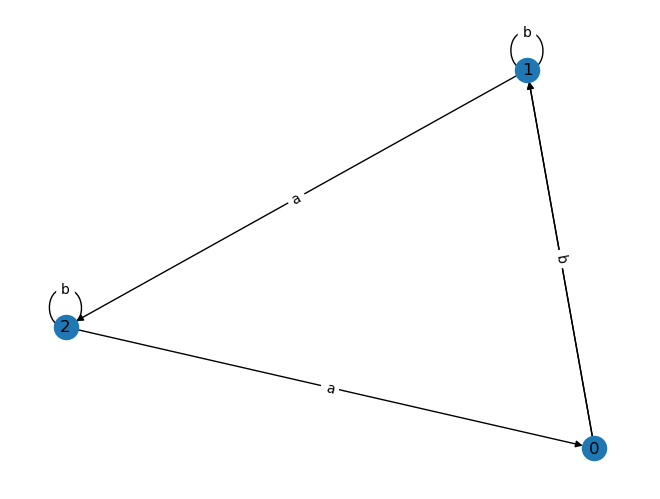

In [45]:
draw_DFA(A1)